<a href="https://colab.research.google.com/github/joseportocarrero-stack/DataScience-Homework/blob/main/FGD_C28R_1A_LABD12_Portocarrero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LABORATORIO DIRIGIDO N.° 12

## Arquitectura de Datos: ¿aguanta tu base cuando el negocio crece?

**Curso:** Fundamentos de Gestión de Datos · TECSUP
**Docente:** Pilar Rocío Sayán Mejía
**Caso:** Farmacia MediSur — base oficial del PMD2
**Duración:** 1 hora y 40 minutos

---

### Elemento de la capacidad terminal

Analiza la volumetría de la base del proyecto, genera un reporte automático de estadísticas y tres gráficos que revelan el comportamiento del negocio, proyecta el crecimiento de los datos a tres años y, con esa evidencia, elige y justifica la arquitectura de datos (Data Lake, Data Warehouse o Data Lakehouse) que la empresa necesitará a escala.

## Caso introductorio

En la Semana 10 migraste la base de MediSur. En la Semana 11 la documentaste con un catálogo de metadatos y la protegiste con roles. Hoy el gerente entra con una noticia y una pregunta.

**La noticia:** MediSur pasa de 6 a 40 sedes en tres años. Además va a empezar a guardar cosas nuevas: **fotos de recetas médicas** escaneadas en cada venta, y **lecturas de sensores** de temperatura de las refrigeradoras, cada 5 minutos, en cada sede (la cadena de frío de las vacunas es obligatoria por ley).

**La pregunta:** *"¿Nuestra base aguanta?"*

Hoy tu base es un archivo SQLite de 336 KB. Cabe en un correo. Pero SQLite guarda tablas: filas y columnas. **¿Dónde metes una foto de una receta? ¿Y millones de lecturas de sensores al año?**

Esa pregunta no se responde con opiniones. Se responde con **evidencia**: cuánto pesa hoy, a qué ritmo crece, qué tipo de datos van a entrar. Eso es lo que vas a construir.

Y hay una trampa esperándote. Cuando intentes graficar las ventas por mes, el gráfico va a salir **roto**. No es un error tuyo: es que los datos están sucios de una forma que nadie había notado, ni siquiera tu pipeline de la Semana 10. Descubrirlo es parte del trabajo de hoy.

Al terminar, tu menú tendrá una sección nueva —**Reportes y gráficos**— y sabrás defender ante el gerente qué arquitectura necesita MediSur y por qué.

## Actividad 1: conceptos previos

Completa con tus propias palabras. No copies de internet.

| # | Concepto | Definición con tus propias palabras |
|---|---|---|
| 1 | Arquitectura de datos | Forma en la que se diseñan y planifican todos los procesos que implican tratamiento y manipulación de datos por parte de una organización.|
| 2 | Volumetría | Acto de medición del espacio físico que ocupa una base de datos en su totalidad y hasta dato por dato.|
| 3 | Dato estructurado | Es un dato estandarizado, listo para usar, limpio y almacenado usualmente en una estructura bidimensional dentro de una base de datos.|
| 4 | Dato no estructurado | Es un dato que no viene en un arreglo bidimensional, puede tener varios formatos, sin un estándar, y usualmente ocupa mucho más espacio que los datos en forma de tablas. Es el más común.|
| 5 | Data Warehouse | Es la forma de almacenamiento de datos estructurados. Puede estar en servidores locales o en la nube.|
| 6 | Data Lake | Es una forma de almacenamiento de datos más reciente, surgida a partir del auge del uso de la internet, consiste típicamente en datos no estructurados guardados en la nube.|
| 7 | Data Lakehouse | Forma de almacenamiento híbrida que combina la flexibilidad y el bajo costo con el orden y la posibilidad de consultas SQL.|
| 8 | Arquitectura Lambda | Es un tipo de diseño de procesamiento de datos que usa un canal para el procesamiento por lotes y otro para procesamiento en tiempo real.|
| 9 | Arquitectura Kappa | Es un tipo de diseño de procesamiento de datos que unifica en un solo canal el procesamiento por lotes y el procesamiento en tiempo real.|
| 10 | Escalabilidad | Capacidad de una arquitectura de datos de manejar un volumen creciente de datos en el tiempo.|

### Las cuatro capas de toda arquitectura de datos

No importa si hablamos de una farmacia o de un banco: todo dato recorre el mismo camino.

| Capa | Qué hace | En MediSur hoy |
|---|---|---|
| **Ingesta** | Por dónde entra el dato | El vendedor teclea la venta; el CSV de la sucursal aliada |
| **Almacenamiento** | Dónde se guarda | `farmacia_migrada.db` (SQLite) |
| **Procesamiento** | Qué se le hace | Tu pipeline ETL de la Semana 10 |
| **Consumo** | Quién lo usa y para qué | Tu menú, los reportes, el gerente |

Cuando alguien dice "vamos a cambiar la arquitectura", casi siempre está hablando de cambiar **una** de estas cuatro capas. Hoy vas a decidir cuál le toca cambiar a MediSur.

### Los tres almacenes: la decisión de fondo

| | **Data Warehouse** | **Data Lake** | **Data Lakehouse** |
|---|---|---|---|
| **Qué guarda** | Solo datos estructurados (tablas) | Todo: tablas, fotos, audio, logs | Todo, pero ordenado |
| **Cuándo se ordena** | Antes de guardar (*schema on write*) | Al leer (*schema on read*) | Al guardar, pero flexible |
| **Ventaja** | Rápido y confiable para reportes | Barato, guarda lo que sea | Lo mejor de los dos |
| **Riesgo** | No entra una foto de receta | Se vuelve un *data swamp*: un pantano donde nadie encuentra nada | Más caro y complejo |
| **Ejemplo peruano** | El BCP para sus reportes regulatorios | Rappi con fotos y GPS de repartidores | Interbank migrando a Databricks |

Fíjate en el riesgo del Data Lake: **data swamp**, pantano de datos. Es lo que pasa cuando guardas todo sin catalogar nada. ¿Te suena? Es exactamente el problema que resolviste la semana pasada con el catálogo de metadatos. **Un Data Lake sin catálogo es un pantano.** Por eso las dos semanas van juntas.

### Lambda y Kappa: ¿cada cuánto llegan los datos?

- **Lambda**: dos caminos en paralelo. Uno **por lotes** (batch: todas las ventas del día, en la noche) y otro **en tiempo real** (streaming: la alarma de la refrigeradora, ahora). Es robusta pero mantienes dos códigos.
- **Kappa**: un solo camino, todo en tiempo real. Más simple, pero exige que todo sea streaming.

Para MediSur: las ventas pueden procesarse en la noche (batch), pero si una refrigeradora sube a 12 °C, **no puedes esperar a mañana**. Ahí ya tienes una pista de qué necesitas.

## Actividad 2: desarrollo práctico en Colab

---

### Paso 1: recuperar el sistema de la Semana 11

Colab olvida todo entre sesiones, así que lo primero es recuperar lo que ya construiste: la base migrada, su catálogo de metadatos y el sistema de roles.

Esta celda es larga pero **no tiene nada nuevo**: es tu trabajo de las semanas 10 y 11. Si te falta algún archivo, lo reconstruye solo. Ejecútala y sigue.

In [ ]:
# ============================================================
# Paso 1: recuperar el proyecto (semanas 10 y 11)
# ============================================================
import sqlite3, os
import pandas as pd
import numpy as np

caso = "03_farmacia_medisur"          # <-- cambia por la carpeta de TU caso asignado
DB_ORIGEN  = "farmacia_legacy.db"
DB_DESTINO = "farmacia_migrada.db"

REPO = "Rociosayan/-PMD2_FGD_Bases_Oficiales_FDG"
url  = f"https://raw.githubusercontent.com/{REPO}/main/casos/{caso}/{caso}.db"

TABLAS_DEL_SISTEMA = {"catalogo_metadatos", "ficha_dublin_core", "resumen_etl"}


def descargar_base_oficial():
    if os.path.exists(DB_ORIGEN):
        return
    import requests
    r = requests.get(url)
    if r.status_code == 200 and r.content[:16] == b"SQLite format 3\x00":
        open(DB_ORIGEN, "wb").write(r.content)
        print("Base oficial descargada.")
    else:
        from google.colab import files
        print("Sube manualmente el .db de tu caso:")
        subida = files.upload(); open(DB_ORIGEN, "wb").write(list(subida.values())[0])


def rehacer_etl_semana10():
    """ETL de la S10, version resumida."""
    o = sqlite3.connect(DB_ORIGEN); d = sqlite3.connect(DB_DESTINO)
    cli = pd.read_sql_query("SELECT * FROM clientes", o).drop_duplicates(
        subset=["num_documento"], keep="first")
    for col in ["nombres", "apellidos", "distrito", "segmento", "tipo_documento"]:
        cli[col] = cli[col].astype("string").str.strip().str.title()
    ok = cli["correo"].str.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$", na=False)
    cli["correo_fue_corregido"] = cli["correo"].notna() & ~ok
    cli.loc[~ok, "correo"] = pd.NA
    cli["correo"]   = cli["correo"].fillna("SIN CORREO REGISTRADO")
    cli["telefono"] = cli["telefono"].fillna("000000000")
    cli.to_sql("clientes_limpio", d, if_exists="replace", index=False)

    op = pd.read_sql_query("SELECT * FROM operaciones", o)
    ids_cli = set(pd.read_sql_query("SELECT id_cliente FROM clientes", o)["id_cliente"])
    ids_emp = set(pd.read_sql_query("SELECT id_empleado FROM empleados", o)["id_empleado"])
    op["monto_original"]     = op["monto_total"]
    op["monto_ajustado"]     = np.where(op["monto_total"] < 0, 0, op["monto_total"])
    op["monto_fue_ajustado"] = op["monto_total"] < 0
    op["cliente_valido"]     = op["id_cliente"].isin(ids_cli)
    op["empleado_valido"]    = op["id_empleado"].isin(ids_emp)
    op.to_sql("ventas_limpia", d, if_exists="replace", index=False)
    d.commit(); o.close(); d.close()
    print("ETL de la S10 reconstruido.")


def completar_tablas_de_apoyo():
    o = sqlite3.connect(DB_ORIGEN); d = sqlite3.connect(DB_DESTINO)
    ya = set(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", d)["name"])
    for t in ["sedes", "empleados", "productos_servicios", "detalle_operacion",
              "pagos", "incidencias"]:
        if t not in ya:
            pd.read_sql_query(f"SELECT * FROM {t}", o).to_sql(t, d, if_exists="replace", index=False)
    d.commit(); o.close(); d.close()


def rehacer_catalogo_semana11():
    """Catalogo de metadatos de la S11, version resumida."""
    c = sqlite3.connect(DB_DESTINO)
    tablas = [t for t in pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", c)["name"]
        if t not in TABLAS_DEL_SISTEMA]
    filas = []
    for tabla in tablas:
        info = pd.read_sql_query(f"PRAGMA table_info({tabla})", c)
        n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {tabla}", c)["n"][0]
        for _, col in info.iterrows():
            filas.append({"tabla": tabla, "columna": col["name"],
                          "tipo_dato": col["type"] or "SIN TIPO",
                          "registros_tabla": n})
    cat = pd.DataFrame(filas)

    DELICADO = {"01_clinica_vitalsalud":("diagnostico","Sensible"),
        "02_banco_crediandes":("saldo_cuenta","Sensible"),
        "03_farmacia_medisur":("condicion_cronica","Sensible"),
        "04_vet_cuidapatas":("motivo_atencion_mascota","Interno"),
        "05_hotel_andes_stay":("nacionalidad","Confidencial"),
        "06_logiexpress_urbano":("direccion_entrega","Confidencial"),
        "07_universidad_aula360":("promedio_notas","Confidencial"),
        "08_muni_data":("tipo_tramite","Interno"),
        "09_retail_online_market":("tarjeta_terminacion","Confidencial"),
        "10_agroexport_sol":("pais_destino","Interno"),
        "11_energyhome_servicios":("consumo_kwh","Confidencial"),
        "12_seguros_protege":("monto_asegurado","Sensible"),
        "13_fastfood_norte":("direccion_delivery","Confidencial"),
        "14_manufactura_metaltec":("linea_credito","Sensible"),
        "15_telconorte_movil":("numero_linea","Confidencial")}
    SENS = {"num_documento":"Confidencial", "correo":"Confidencial", "telefono":"Confidencial",
            "nombres":"Interno", "apellidos":"Interno", "nombre_producto":"Publico",
            "categoria":"Publico", "precio_base":"Publico", "activo":"Publico"}
    col_caso, niv_caso = DELICADO[caso]
    SENS[col_caso] = niv_caso
    cat["sensibilidad"] = cat["columna"].map(lambda x: SENS.get(x, "Interno"))
    cat["descripcion_negocio"] = "Ver catalogo de la Semana 11"
    cat.to_sql("catalogo_metadatos", c, if_exists="replace", index=False)
    c.commit(); c.close()
    print("Catalogo de la S11 reconstruido.")


# --- bootstrap del proyecto
descargar_base_oficial()
if not os.path.exists(DB_DESTINO):
    print("Falta farmacia_migrada.db -> reconstruyo la Semana 10.")
    rehacer_etl_semana10()
completar_tablas_de_apoyo()

conn = sqlite3.connect(DB_DESTINO)
tiene_catalogo = len(pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' AND name='catalogo_metadatos'", conn))
conn.close()
if not tiene_catalogo:
    print("Falta el catalogo -> reconstruyo la Semana 11.")
    rehacer_catalogo_semana11()

conn = sqlite3.connect(DB_DESTINO)
print("\nProyecto listo. Tablas de la base:")
for t in pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"]:
    n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {t}", conn)["n"][0]
    print(f"   {t:22s} {n:5d} registros")


Proyecto listo. Tablas de la base:
   catalogo_metadatos        68 registros
   clientes_limpio          202 registros
   detalle_operacion       2572 registros
   empleados                 40 registros
   incidencias              155 registros
   pagos                   1000 registros
   productos_servicios       30 registros
   sedes                      6 registros
   ventas_limpia           1010 registros


Ahora recuperamos las **funciones** del sistema: los roles, el acceso gobernado por el catálogo y los tres submenús de la Semana 11. Tampoco hay nada nuevo aquí.

In [ ]:
# ============================================================
# Paso 1b: recuperar las funciones del sistema (Semana 11)
# ============================================================
NIVEL_ACCESO = {
    "Vendedor":   {"Publico", "Interno"},
    "Cajero":     {"Publico", "Interno"},
    "Supervisor": {"Publico", "Interno", "Confidencial"},
    "Auditor":    {"Publico", "Interno", "Confidencial", "Sensible"},
    "DataOwner":  {"Publico", "Interno", "Confidencial", "Sensible"},
}

def columnas_visibles(tabla, rol):
    """Le pregunta al catalogo que columnas puede ver este rol."""
    permitidos = NIVEL_ACCESO.get(rol, set())
    if not permitidos:
        return []
    cat = pd.read_sql_query(
        "SELECT columna, sensibilidad FROM catalogo_metadatos WHERE tabla = ?",
        conn, params=(tabla,))
    return [c for c, s in zip(cat["columna"], cat["sensibilidad"]) if s in permitidos]

def consultar(tabla, rol, limite=10):
    cols = columnas_visibles(tabla, rol)
    if not cols:
        return f"ACCESO DENEGADO: el rol {rol} no puede consultar {tabla}."
    return pd.read_sql_query(f"SELECT {', '.join(cols)} FROM {tabla} LIMIT {limite}", conn)

def ver_catalogo_productos():
    return pd.read_sql_query("""
        SELECT id_producto, nombre_producto, categoria, precio_base,
               CASE WHEN activo = 1 THEN 'Si' ELSE 'No' END AS a_la_venta
        FROM productos_servicios ORDER BY categoria, nombre_producto""", conn)

def buscar_medicamento(texto):
    if not texto or not texto.strip():
        return "Escribe algo para buscar."
    d = pd.read_sql_query("""SELECT id_producto, nombre_producto, categoria, precio_base
        FROM productos_servicios WHERE nombre_producto LIKE ? ORDER BY nombre_producto""",
        conn, params=(f"%{texto.strip()}%",))
    return d if len(d) else f"No se encontro ningun medicamento con '{texto}'."

def ver_categorias():
    return pd.read_sql_query("""
        SELECT categoria, COUNT(*) AS productos,
               ROUND(MIN(precio_base),2) AS precio_min, ROUND(MAX(precio_base),2) AS precio_max
        FROM productos_servicios GROUP BY categoria ORDER BY productos DESC""", conn)

def ver_clientes(rol, limite=10):
    return consultar("clientes_limpio", rol, limite)

def buscar_cliente(rol, texto):
    cols = columnas_visibles("clientes_limpio", rol)
    if not cols:
        return f"ACCESO DENEGADO: el rol {rol} no puede consultar clientes."
    if not texto or not texto.strip():
        return "Escribe algo para buscar."
    d = pd.read_sql_query(
        f"""SELECT {', '.join(cols)} FROM clientes_limpio
            WHERE nombres LIKE ? OR apellidos LIKE ? LIMIT 20""",
        conn, params=(f"%{texto.strip()}%", f"%{texto.strip()}%"))
    return d if len(d) else f"No se encontro ningun cliente con '{texto}'."

def ver_diccionario(tabla):
    d = pd.read_sql_query(
        "SELECT * FROM catalogo_metadatos WHERE tabla = ?", conn, params=(tabla,))
    return d if len(d) else f"La tabla '{tabla}' no esta en el catalogo."

def ver_columnas_sensibles(rol):
    if "Sensible" not in NIVEL_ACCESO.get(rol, set()):
        return f"ACCESO DENEGADO: el rol {rol} no puede ver el inventario de datos sensibles."
    return pd.read_sql_query("""SELECT tabla, columna, sensibilidad FROM catalogo_metadatos
        WHERE sensibilidad IN ('Sensible','Confidencial')
        ORDER BY CASE sensibilidad WHEN 'Sensible' THEN 1 ELSE 2 END, tabla""", conn)

def tablas_del_catalogo():
    return pd.read_sql_query(
        "SELECT DISTINCT tabla FROM catalogo_metadatos ORDER BY tabla", conn)["tabla"].tolist()

print("Sistema de la Semana 11 recuperado.")
print("Prueba: el Vendedor ve", len(columnas_visibles("clientes_limpio", "Vendedor")),
      "columnas y el Auditor ve", len(columnas_visibles("clientes_limpio", "Auditor")))

Sistema de la Semana 11 recuperado.
Prueba: el Vendedor ve 9 columnas y el Auditor ve 13


### Paso 2: volumetría — ¿cuánto pesa realmente tu base?

**Volumetría** es medir cuánto ocupan tus datos. Suena aburrido hasta que descubres que es lo único que convierte una discusión de arquitectura en una decisión técnica.

Sin volumetría, la reunión es: *"yo creo que deberíamos migrar a la nube"*. Con volumetría es: *"crecemos 40 MB al mes, en 3 años son 1.4 GB, y SQLite empieza a sufrir con escrituras concurrentes de 40 sedes"*.

Vamos a medir tres cosas: cuántos registros hay, cuánto pesa cada tabla y cuál es la tabla más pesada.

In [ ]:
# ============================================================
# Paso 2: volumetria de la base
# ============================================================
def volumetria():
    """Cuantos registros y cuanto pesa cada tabla."""
    tablas = [t for t in pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"]
        if t not in TABLAS_DEL_SISTEMA]

    filas = []
    for t in tablas:
        df = pd.read_sql_query(f"SELECT * FROM {t}", conn)
        peso_kb = df.memory_usage(deep=True).sum() / 1024
        filas.append({"tabla": t,
                      "registros": len(df),
                      "columnas": len(df.columns),
                      "peso_kb": round(peso_kb, 1),
                      "kb_por_registro": round(peso_kb / len(df), 3) if len(df) else 0})
    v = pd.DataFrame(filas).sort_values("peso_kb", ascending=False)
    return v.reset_index(drop=True)


vol = volumetria()
total_reg = vol["registros"].sum()
total_kb  = vol["peso_kb"].sum()
archivo_kb = os.path.getsize(DB_DESTINO) / 1024

print("VOLUMETRIA DE LA BASE DEL PROYECTO")
print("=" * 46)
display(vol)
print(f"Registros en toda la base : {total_reg:,}")
print(f"Peso de los datos en RAM  : {total_kb:,.1f} KB")
print(f"Peso del archivo .db      : {archivo_kb:,.1f} KB")
print(f"Tabla mas pesada          : {vol.iloc[0]['tabla']} ({vol.iloc[0]['peso_kb']:,.1f} KB)")

VOLUMETRIA DE LA BASE DEL PROYECTO


,tabla,registros,columnas,peso_kb,kb_por_registro
0,ventas_limpia,1010,14,311.9,0.309
1,pagos,1000,7,246.1,0.246
2,clientes_limpio,202,13,135.9,0.673
3,detalle_operacion,2572,6,120.7,0.047
4,incidencias,155,7,48.4,0.312
5,empleados,40,10,19.0,0.476
6,productos_servicios,30,6,6.7,0.224
7,sedes,6,5,1.7,0.288


Registros en toda la base : 5,015
Peso de los datos en RAM  : 890.4 KB
Peso del archivo .db      : 312.0 KB
Tabla mas pesada          : ventas_limpia (311.9 KB)


**Pregunta 1:** ¿Cuál es la tabla más pesada y por qué crees que lo es? Fíjate en que no siempre es la que tiene más registros: mira también la columna `kb_por_registro`. ¿Qué hace que un registro pese más que otro?

Respuesta: Ventas_limpia es la tabla más pesada porque el producto (peso_kb) de su número de registros, multiplicado por los Kilobytes por registro, es el más alto. Lo que puede hacer que un registro pese más que el registro de otra tabla es el peso del dato que hay en cada celda y el número de columnas en cada registro.

### Paso 3: reporte automático de estadísticas

El gerente no va a leer 1.010 filas de ventas. Quiere saber: *¿cuánto vendemos en promedio? ¿cuál es la venta más grande? ¿hay algo raro?*

`df.describe()` de pandas responde todo eso en una línea. Es la herramienta más rentable que aprenderás este semestre: te da mínimo, máximo, promedio, mediana y desviación de cada columna numérica.

Y sirve para algo más importante que el reporte: **detectar lo imposible**. Si el mínimo de un monto es negativo, ahí hay un problema.

In [ ]:
# ============================================================
# Paso 3: reporte automatico de estadisticas
# ============================================================
def reporte_estadisticas():
    """Estadisticas de las columnas numericas del negocio."""
    ventas = pd.read_sql_query(
        "SELECT monto_total, monto_ajustado FROM ventas_limpia", conn)
    productos = pd.read_sql_query("SELECT precio_base FROM productos_servicios", conn)
    detalle = pd.read_sql_query(
        "SELECT cantidad, precio_unitario, subtotal FROM detalle_operacion", conn)

    todo = pd.concat([ventas, productos, detalle], axis=1)
    return todo.describe().round(2)


est = reporte_estadisticas()
print("REPORTE AUTOMATICO DE ESTADISTICAS")
print("=" * 46)
display(est)

# Lo que el describe() delata
print("\nLo que este reporte te esta gritando:")
minimo = est.loc["min", "monto_total"]
print(f"   El monto MINIMO de una venta es: S/. {minimo}")
if minimo < 0:
    print("   -> Una venta NEGATIVA es imposible. Son los montos que la S10 detecto.")
    print("   -> Por eso existe la columna monto_ajustado: ahi ya estan corregidos.")
print(f"   El monto MAXIMO de una venta es: S/. {est.loc['max','monto_total']}")
print(f"   El promedio por venta es       : S/. {est.loc['mean','monto_ajustado']}")

REPORTE AUTOMATICO DE ESTADISTICAS


,monto_total,monto_ajustado,precio_base,cantidad,precio_unitario,subtotal
count,1010.00,1010.00,30.00,2572.00,2572.00,2572.00
mean,483.79,502.58,36.56,3.49,36.77,127.41
std,911.95,873.76,27.31,1.71,26.72,118.13
min,-4026.67,0.00,5.00,1.00,5.00,5.00
25%,146.52,146.52,16.36,2.00,16.00,43.32
50%,306.12,306.12,25.71,3.00,26.05,90.00
75%,503.16,503.16,50.36,5.00,50.87,161.40
max,7287.71,7287.71,110.00,6.00,110.00,660.00



Lo que este reporte te esta gritando:
   El monto MINIMO de una venta es: S/. -4026.67
   -> Una venta NEGATIVA es imposible. Son los montos que la S10 detecto.
   -> Por eso existe la columna monto_ajustado: ahi ya estan corregidos.
   El monto MAXIMO de una venta es: S/. 7287.71
   El promedio por venta es       : S/. 502.58


**Pregunta 2:** Mira la fila `min` de la columna `monto_total`. ¿Qué valor tiene y por qué es imposible en un negocio real? Ahora compara con `monto_ajustado`. ¿Qué hizo tu pipeline de la Semana 10 y por qué guardó **las dos** columnas en vez de solo la corregida?

Respuesta: La celda definida por la fila min y la columna monto_total contiene un valor igual a -4026.67 soles. Si es imposible en un negocio real es porque eso indicaría que MediSur le paga a los clientes por llevarse un producto que MediSur compró antes. El pipeline de la semana 10 toma los valores de la columna monto_total y los compara con el valor cero. Si el número es negativo, lo transforma en cero, lo cual convierte una transacción en donde sí hubo una entrega de producto y una salida de inventario en una donación no planificada. Creo que fue correcto guardar ambas columnas para documentar el proceso de imputación y dejar que un auditor o el Data Owner pueda revisar todo el registro en detalle, usando el catálogo de metadatos para ver la regla de negocio específica a esa variable, ya que un monto negativo también podría significar otra cosa, como una devolución o un descuento a favor de un cliente.

### Paso 4: gráfico 1 — ¿dónde está el volumen?

El primer gráfico responde la pregunta de la arquitectura: **¿qué tabla va a explotar primero cuando el negocio crezca?**

Fíjate en algo importante: este gráfico **no expone a ningún cliente**. Solo dice cuántas filas hay por tabla. Por eso cualquier rol puede verlo, incluso el vendedor. Se llama **agregación**: cuando resumes datos, los individuos desaparecen y el dato deja de ser personal.

Es la otra cara de lo que hiciste la semana pasada. En la S11 protegiste columnas ocultándolas. Aquí compartes información **sin ocultar nada**, porque al agregar ya no hay a quién exponer.

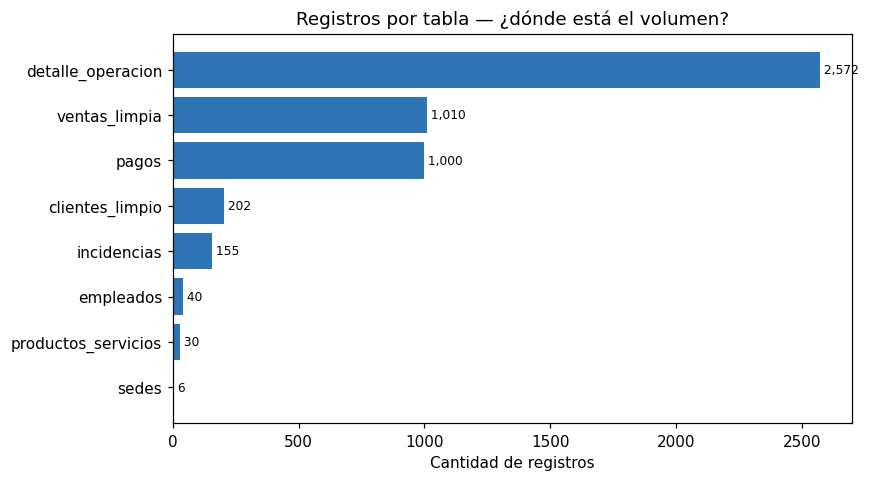

In [ ]:
# ============================================================
# Paso 4: grafico 1 - registros por tabla
# ============================================================
import matplotlib
from matplotlib.figure import Figure


def grafico_registros_por_tabla():
    """Que tabla concentra el volumen de la base."""
    v = volumetria().sort_values("registros", ascending=True)
    fig = Figure(figsize=(8, 4.5)); ax = fig.subplots()
    ax.barh(v["tabla"], v["registros"], color="#2E75B6")
    ax.set_title("Registros por tabla — ¿dónde está el volumen?")
    ax.set_xlabel("Cantidad de registros")
    for i, (t, n) in enumerate(zip(v["tabla"], v["registros"])):
        ax.text(n, i, f" {n:,}", va="center", fontsize=8)
    fig.tight_layout()
    return fig


fig1 = grafico_registros_por_tabla()
fig1.savefig("g1_registros_por_tabla.png", bbox_inches="tight", dpi=110)
from IPython.display import Image
Image("g1_registros_por_tabla.png")

### Paso 5: gráfico 2 — ventas por mes, y la trampa

Ahora el gráfico que le importa al gerente: **¿estamos creciendo?**

Aquí está la trampa que te anuncié. Ejecuta la celda tal como está y **mira el resultado antes de seguir leyendo**.

In [ ]:
# ============================================================
# Paso 5a: ventas por mes -- primer intento (INGENUO)
# ============================================================
ventas = pd.read_sql_query("SELECT fecha_operacion, monto_ajustado FROM ventas_limpia", conn)

# Agrupamos por los primeros 7 caracteres de la fecha: "2026-01" -> enero 2026
ventas["mes"] = ventas["fecha_operacion"].str[:7]
por_mes = ventas.groupby("mes").size()

print("Meses que encontro el agrupamiento ingenuo:", len(por_mes))
print()
print(por_mes.head(15).to_string())
print("...")
print()
print("Si esperabas 6 meses (enero a junio) y ves decenas de grupos raros,")
print("no te has equivocado: los DATOS estan sucios. Sigue al paso 5b.")

Meses que encontro el agrupamiento ingenuo: 72

mes
01/01/2    1
01/03/2    1
01/05/2    1
01/06/2    2
02/03/2    1
02/04/2    2
02/06/2    2
04/01/2    1
04/03/2    1
05/01/2    1
05/03/2    1
06/03/2    3
06/05/2    1
07/02/2    2
07/03/2    1
...

Si esperabas 6 meses (enero a junio) y ves decenas de grupos raros,
no te has equivocado: los DATOS estan sucios. Sigue al paso 5b.


#### ¿Qué pasó?

Si esperabas 6 barras (enero a junio) y te salieron decenas de grupos como `01/01/2`, `19/02/2`, `24/03/2`, no cometiste ningún error.

**La columna `fecha_operacion` tiene dos formatos mezclados:**

| Formato | Ejemplo | Cuántos |
|---|---|---|
| ISO | `2026-01-15` | 930 |
| Día/Mes/Año | `19/01/2026` | 80 |

Cuando cortas `"2026-01-15"[:7]` obtienes `"2026-01"`, que es enero. Pero cuando cortas `"19/01/2026"[:7]` obtienes `"19/01/2"`, que no es nada.

Y aquí lo importante: **tu pipeline de la Semana 10 no detectó esto**. Limpiaste duplicados, correos y montos negativos, pero las fechas pasaron intactas. Nadie las miró, porque nadie las había necesitado hasta hoy.

Esto es un problema de **consistencia**: el mismo dato guardado de dos maneras distintas. Es una de las cinco dimensiones de la calidad de datos que vas a estudiar la semana que viene.

> **Ojo con la lección de fondo:** los datos sucios no avisan. Se descubren cuando alguien intenta *usarlos*. Por eso los reportes y los gráficos son, además de una herramienta de negocio, un **detector de problemas de calidad**.

Vamos a estandarizar las fechas para poder graficar. Ojo: hoy solo lo hacemos **en memoria**, para el gráfico. La corrección formal, guardada en la base, es trabajo de la Semana 13.

Ventas totales           : 1,010
Fechas que no se pudieron leer: 0
Rango real de operaciones: 2026-01-01 a 2026-06-28

Ahora si: los meses reales del negocio


,ventas,monto
fecha,,
2026-01,156,82172.91
2026-02,166,78433.05
2026-03,182,85876.19
2026-04,171,98518.68
2026-05,147,54469.58
2026-06,188,108135.70


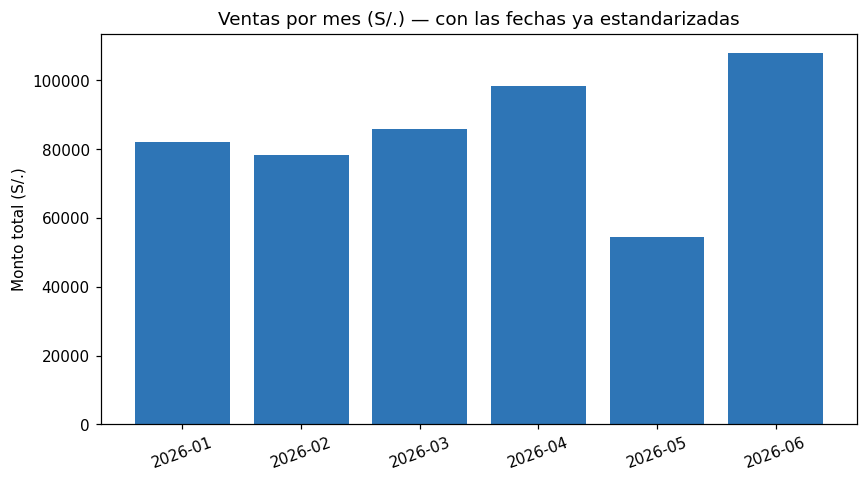

In [ ]:
# ============================================================
# Paso 5b: estandarizar las fechas y graficar de verdad
# ============================================================
def estandarizar_fechas(serie):
    """Convierte una columna con formatos mezclados a fecha real.

    Estrategia: intentamos el formato ISO; lo que falle, lo intentamos como
    dia/mes/anio. errors='coerce' convierte en NaT lo que no se pueda leer,
    en vez de reventar. Asi nos enteramos de cuanto NO se pudo salvar.
    """
    f = pd.to_datetime(serie, format="%Y-%m-%d", errors="coerce")
    faltan = f.isna()
    f[faltan] = pd.to_datetime(serie[faltan], format="%d/%m/%Y", errors="coerce")
    return f


ventas["fecha"] = estandarizar_fechas(ventas["fecha_operacion"])

sin_convertir = int(ventas["fecha"].isna().sum())
print(f"Ventas totales           : {len(ventas):,}")
print(f"Fechas que no se pudieron leer: {sin_convertir}")
print(f"Rango real de operaciones: {ventas['fecha'].min().date()} a {ventas['fecha'].max().date()}")


def grafico_ventas_por_mes():
    """Evolucion mensual del negocio, con las fechas ya estandarizadas."""
    v = pd.read_sql_query("SELECT fecha_operacion, monto_ajustado FROM ventas_limpia", conn)
    v["fecha"] = estandarizar_fechas(v["fecha_operacion"])
    v = v.dropna(subset=["fecha"])
    m = v.groupby(v["fecha"].dt.to_period("M")).agg(
        ventas=("monto_ajustado", "size"), monto=("monto_ajustado", "sum"))
    m.index = m.index.astype(str)

    fig = Figure(figsize=(8, 4.5)); ax = fig.subplots()
    ax.bar(m.index, m["monto"], color="#2E75B6")
    ax.set_title("Ventas por mes (S/.) — con las fechas ya estandarizadas")
    ax.set_ylabel("Monto total (S/.)")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    return fig, m


fig2, resumen_mes = grafico_ventas_por_mes()
print("\nAhora si: los meses reales del negocio")
display(resumen_mes)
fig2.savefig("g2_ventas_por_mes.png", bbox_inches="tight", dpi=110)
Image("g2_ventas_por_mes.png")

**Pregunta 3:** ¿Cuántos "meses" encontró el agrupamiento ingenuo y cuántos hay en realidad? Explica con tus palabras por qué `"19/01/2026"[:7]` produce basura. Luego responde lo importante: **¿por qué tu pipeline de la Semana 10 no detectó este problema?**

Respuesta: El agrupamiento ingenuo encontró 72 meses, en realidad, solamente hay 6. "19/01/2026"[:7] produce basura porque toma los siete primeros caracteres de una celda en donde se asume que existe un único formato de fecha sin haberlo verificado. Para este caso, devuelve 19/01/2, lo que no puede interpretarse de manera inequívoca como una fecha.

### Paso 6: gráfico 3 — ¿qué nos da de comer?

El tercer gráfico responde la pregunta del negocio: **¿qué categoría genera más ingresos?**

Este cruza dos tablas con un `JOIN`: el detalle de cada venta y el catálogo de productos. Es el gráfico que va a ir en tu informe gerencial del PMD2, así que hazlo bien.

VENTAS POR CATEGORIA


,categoria,ventas,total,ticket_promedio
0,Suplemento,441,94555.61,178.41
1,Controlado,441,93366.08,164.67
2,Marca,417,62501.71,127.29
3,Cuidado personal,416,46854.65,90.80
4,Genérico,381,30417.70,65.00


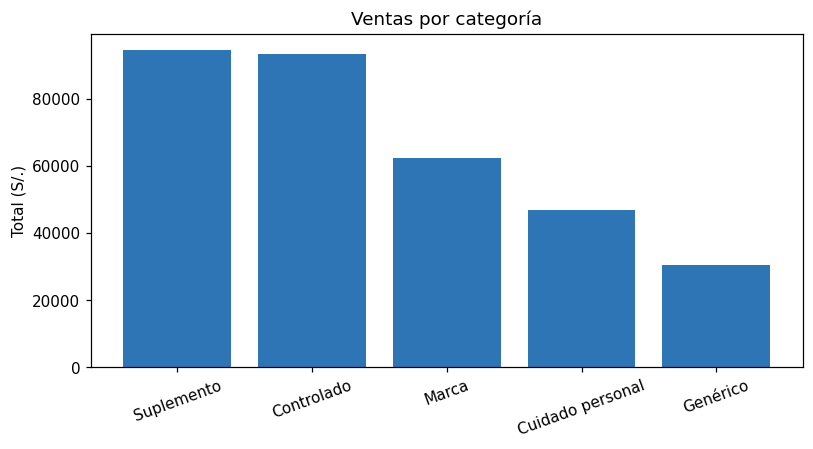

In [ ]:
# ============================================================
# Paso 6: grafico 3 - ventas por categoria
# ============================================================
def reporte_ventas():
    """Cuanto factura cada familia de productos. JOIN entre detalle y catalogo."""
    q = """SELECT p.categoria, ROUND(SUM(d.subtotal), 2) AS total
           FROM detalle_operacion d
           JOIN productos_servicios p ON d.id_producto = p.id_producto
           GROUP BY p.categoria
           ORDER BY total DESC"""
    d = pd.read_sql_query(q, conn)

    fig = Figure(figsize=(7.5, 4.2)); ax = fig.subplots()
    ax.bar(d["categoria"], d["total"], color="#2E75B6")
    ax.set_title("Ventas por categoría")
    ax.set_ylabel("Total (S/.)")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    return fig


def tabla_ventas_por_categoria():
    return pd.read_sql_query("""
        SELECT p.categoria,
               COUNT(DISTINCT d.id_operacion) AS ventas,
               ROUND(SUM(d.subtotal), 2)      AS total,
               ROUND(AVG(d.subtotal), 2)      AS ticket_promedio
        FROM detalle_operacion d
        JOIN productos_servicios p ON d.id_producto = p.id_producto
        GROUP BY p.categoria ORDER BY total DESC""", conn)


print("VENTAS POR CATEGORIA")
display(tabla_ventas_por_categoria())
fig3 = reporte_ventas()
fig3.savefig("g3_ventas_por_categoria.png", bbox_inches="tight", dpi=110)
Image("g3_ventas_por_categoria.png")

**Pregunta 4:** ¿Qué categoría factura más y cuál menos? Mira también el `ticket_promedio`. ¿Es lo mismo vender mucho que facturar mucho? Da una recomendación de negocio para MediSur basada en este gráfico.

Respuesta: La categoría de suplementos es la que factura más, con un total de ventas de 94555.61 soles, en tanto que la categoría de menos facturación es la de genéricos, con un total de ventas igual a 30417.70 soles. Vender mucho no necesariamente es igual a facturar mucho, ya que las ventas más frecuentes podrían corresponder a productos que reporten bajos ingresos, pero para este caso particular, el producto más vendido es el que reporta más ganancias. Con base en este gráfico, que es coherente con un escenario real, recomendaría una inversión adicional (sin descuidar las otras categorías), tanto en publicidad como en inventario, para la categoría de suplementos, con un énfasis en los suplementos usados por personas que entrenan con regularidad en ginmasios.

### Paso 7: proyección — ¿y en tres años?

Tienes 6 meses de datos y 6 sedes. El gerente habla de 3 años y 40 sedes. Proyectemos.

La proyección es una regla de tres honesta: si hoy 6 sedes generan X ventas al mes, 40 sedes generarán X × (40/6). Y a eso le sumamos lo nuevo: las **recetas escaneadas** y los **sensores de temperatura**.

Ahí es donde la cosa cambia de escala. Presta atención a las unidades.

In [ ]:
# ============================================================
# Paso 7: proyeccion de crecimiento a 3 anios
# ============================================================
SEDES_HOY    = 6
SEDES_FUTURO = 40
MESES_DATOS  = 6
ANIOS        = 3

ventas_hoy   = pd.read_sql_query("SELECT COUNT(*) n FROM ventas_limpia", conn)["n"][0]
ventas_mes   = ventas_hoy / MESES_DATOS
kb_por_venta = vol.loc[vol["tabla"] == "ventas_limpia", "kb_por_registro"].values[0]

# 1) Ventas: crecen con las sedes
factor        = SEDES_FUTURO / SEDES_HOY
ventas_mes_f  = ventas_mes * factor
ventas_3a     = ventas_mes_f * 12 * ANIOS
mb_ventas_3a  = ventas_3a * kb_por_venta / 1024

# 2) Recetas escaneadas: 1 foto por venta, ~800 KB cada una
KB_POR_FOTO   = 800
mb_fotos_3a   = ventas_3a * KB_POR_FOTO / 1024

# 3) Sensores: 1 lectura cada 5 min, por sede, ~0.1 KB
LECTURAS_DIA  = (24 * 60) / 5
lecturas_3a   = LECTURAS_DIA * 365 * ANIOS * SEDES_FUTURO
mb_sensores_3a = lecturas_3a * 0.1 / 1024

proyeccion = pd.DataFrame([
    {"fuente": "Ventas (tablas)",      "registros_3_anios": int(ventas_3a),
     "MB_en_3_anios": round(mb_ventas_3a, 1),   "tipo": "Estructurado"},
    {"fuente": "Recetas escaneadas",   "registros_3_anios": int(ventas_3a),
     "MB_en_3_anios": round(mb_fotos_3a, 1),    "tipo": "NO estructurado"},
    {"fuente": "Sensores de frio",     "registros_3_anios": int(lecturas_3a),
     "MB_en_3_anios": round(mb_sensores_3a, 1), "tipo": "Semiestructurado / streaming"},
])

print(f"Hoy      : {SEDES_HOY} sedes, {ventas_mes:,.0f} ventas al mes, {archivo_kb:.0f} KB")
print(f"En 3 anios: {SEDES_FUTURO} sedes (x{factor:.1f})")
print()
display(proyeccion)

total_gb = proyeccion["MB_en_3_anios"].sum() / 1024
print(f"TOTAL proyectado a 3 anios: {proyeccion['MB_en_3_anios'].sum():,.0f} MB  =  {total_gb:,.2f} GB")
print(f"Crecimiento respecto de hoy: x{(proyeccion['MB_en_3_anios'].sum()*1024)/archivo_kb:,.0f}")
print()
print(f"Lecturas de sensores en 3 anios: {lecturas_3a:,.0f}")
print("Comparalo con las", f"{ventas_hoy:,}", "ventas que tienes hoy.")

Hoy      : 6 sedes, 168 ventas al mes, 312 KB
En 3 anios: 40 sedes (x6.7)



,fuente,registros_3_anios,MB_en_3_anios,tipo
0,Ventas (tablas),40400,12.2,Estructurado
1,Recetas escaneadas,40400,31562.5,NO estructurado
2,Sensores de frio,12614400,1231.9,Semiestructurado / streaming


TOTAL proyectado a 3 anios: 32,807 MB  =  32.04 GB
Crecimiento respecto de hoy: x107,673

Lecturas de sensores en 3 anios: 12,614,400
Comparalo con las 1,010 ventas que tienes hoy.


**Pregunta 5:** ¿Cuántos MB proyectaste a 3 años y cuántas veces más grande es que tu base de hoy? Ahora lo importante: de las tres fuentes, **¿cuál crece más y de qué tipo es?** ¿Qué te dice eso sobre si SQLite y las tablas siguen alcanzando?

Respuesta: Se proyectan 32807 MB a tres años. Lo anterior es (32807 MB*(1024 KB/1 MB))/312 KB = 107674,26 veces más grande que la base de datos de hoy. De las tres fuentes, la que crece más en cuanto a número de registros es la de sensores de frío, con 12614400 registros; y la que más crece, en cuanto a cantidad de MB es la de recetas escaneadas. Para saber si SQLite será suficiente, creo que sería necesario averiguar primero las capacidades de SQLite y, de acuerdo a éstas, es físicamente posible, aunque inviable en la práctica sin algunos ajustes.

### Paso 8: elegir la arquitectura, con evidencia

Ya tienes los números. Ahora la decisión.

La regla es simple y casi nadie la aplica: **el tipo de dato manda sobre el almacén**.

- ¿Solo tablas? → **Data Warehouse**.
- ¿Tablas + fotos + sensores? → un Warehouse **no puede**. No existe la columna "foto de receta" en SQL.
- ¿Todo junto pero sin volverse un pantano? → **Lakehouse**.

La función de abajo no adivina: **decide con tus datos**.

In [ ]:
# ============================================================
# Paso 8: recomendacion de arquitectura basada en evidencia
# ============================================================
COMPARACION = pd.DataFrame([
    {"criterio": "Guarda tablas",              "Data Warehouse": "Si", "Data Lake": "Si",  "Lakehouse": "Si"},
    {"criterio": "Guarda fotos y archivos",    "Data Warehouse": "No", "Data Lake": "Si",  "Lakehouse": "Si"},
    {"criterio": "Guarda streaming (sensores)","Data Warehouse": "Con dificultad", "Data Lake": "Si", "Lakehouse": "Si"},
    {"criterio": "Rapido para reportes",       "Data Warehouse": "Si", "Data Lake": "No",  "Lakehouse": "Si"},
    {"criterio": "Costo de almacenamiento",    "Data Warehouse": "Alto", "Data Lake": "Bajo", "Lakehouse": "Medio"},
    {"criterio": "Riesgo de data swamp",       "Data Warehouse": "Nulo", "Data Lake": "ALTO", "Lakehouse": "Bajo (si hay catalogo)"},
])


def recomendar_arquitectura(tipos_de_dato, gb_proyectados, necesita_tiempo_real):
    """Recomienda un almacen segun la evidencia, no segun la moda."""
    no_estructurados = [t for t in tipos_de_dato if t != "Estructurado"]

    if not no_estructurados:
        almacen = "Data Warehouse"
        razon = "Todos los datos son tablas. Un Warehouse es lo mas rapido y confiable."
    elif gb_proyectados < 1:
        almacen = "Base relacional actual (SQLite/PostgreSQL)"
        razon = "Hay datos no estructurados, pero el volumen es tan bajo que no justifica migrar."
    else:
        almacen = "Data Lakehouse"
        razon = ("Hay datos no estructurados (fotos) y streaming (sensores) que un Warehouse no "
                 "puede guardar, pero tambien se necesitan reportes rapidos, que un Lake puro no da.")

    flujo = "Kappa (todo en tiempo real)" if necesita_tiempo_real and gb_proyectados < 10 \
            else ("Lambda (lotes + tiempo real)" if necesita_tiempo_real else "Batch (por lotes)")

    return almacen, razon, flujo


tipos = proyeccion["tipo"].tolist()
almacen, razon, flujo = recomendar_arquitectura(
    tipos_de_dato=tipos,
    gb_proyectados=total_gb,
    necesita_tiempo_real=True,   # la alarma de la refrigeradora no puede esperar
)

print("COMPARACION DE ARQUITECTURAS")
display(COMPARACION)

print("=" * 66)
print("RECOMENDACION PARA FARMACIA MEDISUR")
print("=" * 66)
print(f"Tipos de dato a 3 anios : {', '.join(sorted(set(tipos)))}")
print(f"Volumen proyectado      : {total_gb:.2f} GB")
print(f"Necesita tiempo real    : Si (cadena de frio: alarma inmediata)")
print()
print(f"  ALMACEN RECOMENDADO   : {almacen}")
print(f"  RAZON                 : {razon}")
print(f"  FLUJO RECOMENDADO     : {flujo}")
print()
print("  Y una advertencia: un Lakehouse SIN catalogo de metadatos es un pantano.")
print("  El catalogo que construiste en la Semana 11 es lo que lo hace viable.")

COMPARACION DE ARQUITECTURAS


,criterio,Data Warehouse,Data Lake,Lakehouse
0,Guarda tablas,Si,Si,Si
1,Guarda fotos y archivos,No,Si,Si
2,Guarda streaming (sensores),Con dificultad,Si,Si
3,Rapido para reportes,Si,No,Si
4,Costo de almacenamiento,Alto,Bajo,Medio
5,Riesgo de data swamp,Nulo,ALTO,Bajo (si hay catalogo)


RECOMENDACION PARA FARMACIA MEDISUR
Tipos de dato a 3 anios : Estructurado, NO estructurado, Semiestructurado / streaming
Volumen proyectado      : 32.04 GB
Necesita tiempo real    : Si (cadena de frio: alarma inmediata)

  ALMACEN RECOMENDADO   : Data Lakehouse
  RAZON                 : Hay datos no estructurados (fotos) y streaming (sensores) que un Warehouse no puede guardar, pero tambien se necesitan reportes rapidos, que un Lake puro no da.
  FLUJO RECOMENDADO     : Lambda (lotes + tiempo real)

  Y una advertencia: un Lakehouse SIN catalogo de metadatos es un pantano.
  El catalogo que construiste en la Semana 11 es lo que lo hace viable.


**Pregunta 6:** ¿Qué arquitectura recomendó la función para MediSur y con qué razón? Ahora piensa al revés: **¿qué tendría que cambiar** para que la recomendación fuera un Data Warehouse simple? Modifica los argumentos de `recomendar_arquitectura()` y compruébalo.

Respuesta: La función recomendó para MediSur una arquitectura híbrida porque entre los datos que manejará la base de datos habrán fotos y lecturas de sensores, junto con datos estructurados.

### Paso 9: el diagrama — dibuja el flujo

Una arquitectura que no se puede dibujar en una hoja no se entiende. Vamos a dibujar las cuatro capas: **ingesta → almacenamiento → procesamiento → consumo**, hoy y a tres años.

In [ ]:
# ============================================================
# Paso 9: diagrama de la arquitectura (hoy vs a 3 anios)
# ============================================================
def diagrama_arquitectura():
    hoy = f"""
    ARQUITECTURA HOY  ({archivo_kb:.0f} KB, {SEDES_HOY} sedes)
    ==========================================================================
      INGESTA              ALMACENAMIENTO       PROCESAMIENTO      CONSUMO
    --------------      ------------------    ---------------   --------------
     Vendedor (menu)  ->                                          Menu por roles
     CSV sucursal     ->  farmacia_migrada  ->  ETL Semana 10  -> Reportes
     Base legacy      ->  .db (SQLite)         pandas            Graficos
                          + catalogo S11                          Gerente
    """

    futuro = f"""
    ARQUITECTURA A 3 ANIOS  ({total_gb:.1f} GB, {SEDES_FUTURO} sedes)  ->  {almacen}
    ==========================================================================
      INGESTA                ALMACENAMIENTO        PROCESAMIENTO     CONSUMO
    -----------------     -------------------    ---------------  --------------
     40 sedes (POS)    ->   ZONA BRONCE          ETL por lotes  -> Dashboards
     Recetas (fotos)   ->   crudo, tal cual      (ventas, noche)   Alertas frio
     Sensores de frio  ->        |                     |            Reportes
     CSV aliados       ->   ZONA PLATA           Streaming      -> Auditoria
                            limpio y validado    (sensores, ya)    Data Science
                                |
                            ZONA ORO
                            listo para negocio
                                |
                         CATALOGO DE METADATOS  <- sin esto, es un PANTANO
                         (lo tuyo de la Semana 11, a escala)
    """
    return hoy, futuro


hoy, futuro = diagrama_arquitectura()
print(hoy)
print(futuro)

# Guardamos el diagrama como evidencia del proyecto
with open("arquitectura_medisur.txt", "w", encoding="utf-8") as f:
    f.write(hoy + "\n" + futuro)
print("Diagrama guardado en arquitectura_medisur.txt")


    ARQUITECTURA HOY  (312 KB, 6 sedes)
      INGESTA              ALMACENAMIENTO       PROCESAMIENTO      CONSUMO
    --------------      ------------------    ---------------   --------------
     Vendedor (menu)  ->                                          Menu por roles
     CSV sucursal     ->  farmacia_migrada  ->  ETL Semana 10  -> Reportes
     Base legacy      ->  .db (SQLite)         pandas            Graficos
                          + catalogo S11                          Gerente
    

    ARQUITECTURA A 3 ANIOS  (32.0 GB, 40 sedes)  ->  Data Lakehouse
      INGESTA                ALMACENAMIENTO        PROCESAMIENTO     CONSUMO
    -----------------     -------------------    ---------------  --------------
     40 sedes (POS)    ->   ZONA BRONCE          ETL por lotes  -> Dashboards
     Recetas (fotos)   ->   crudo, tal cual      (ventas, noche)   Alertas frio
     Sensores de frio  ->        |                     |            Reportes
     CSV aliados       ->   ZONA P

**Pregunta 7:** En el diagrama a 3 años aparecen tres zonas: **bronce** (crudo), **plata** (limpio) y **oro** (listo para el negocio). Explica qué haría tu ETL de la Semana 10 en ese esquema: ¿entre qué zonas viviría? ¿Y dónde encaja el catálogo de la Semana 11?

Respuesta: El ETL de la semana 10 se encargaría de extraer los datos de la capa o zona bronce a la zona plata, en donde les aplicaría los métodos de limpieza. Estaría en la zona plata, entre las zonas bronce y oro. El catálogo de metadatos estaría presente de forma transversal en toda la arquitectura.

### Paso 10: el menú crece — Reportes y gráficos

Todo lo de hoy son funciones sueltas. El gerente no ejecuta celdas: usa el menú.

Le agregamos la opción **4) Reportes y gráficos**. Fíjate en que el menú principal **no se reescribe desde cero**: es el mismo de la Semana 11 con una opción más. Así va a crecer hasta la Semana 15.

Y una decisión de diseño que ya discutimos: los reportes son **agregados**, así que no exponen a ningún cliente y cualquier rol puede verlos. La volumetría, en cambio, es información interna de la empresa: la dejamos para roles con acceso Confidencial hacia arriba.

In [ ]:
# ============================================================
# Paso 10: EL MENU de la Semana 12
# ============================================================
ROLES_MENU = {"1": "Vendedor", "2": "Cajero", "3": "Supervisor",
              "4": "Auditor",  "5": "DataOwner"}

def _mostrar(r):
    if isinstance(r, pd.DataFrame):
        display(r)
    else:
        print(r)

def _descargar(ruta):
    try:
        from google.colab import files; files.download(ruta)
        print("  Descargado:", ruta)
    except Exception:
        print("  Guardado en el entorno:", ruta)


# ---------------------------------------- submenus de la Semana 11 (sin cambios)
def submenu_productos(rol):
    while True:
        print("\n--- CATALOGO DE PRODUCTOS ---")
        print("  1) Ver todo el catalogo   2) Buscar un medicamento")
        print("  3) Ver por categoria      0) Volver")
        op = input("  Opcion: ").strip()
        if op == "0": break
        elif op == "1": _mostrar(ver_catalogo_productos())
        elif op == "2": _mostrar(buscar_medicamento(input("  Nombre del medicamento: ")))
        elif op == "3": _mostrar(ver_categorias())
        else: print("  Opcion invalida.")

def submenu_clientes(rol):
    while True:
        print("\n--- CLIENTES ---")
        print("  1) Ver lista   2) Buscar un cliente   0) Volver")
        op = input("  Opcion: ").strip()
        if op == "0": break
        elif op == "1":
            _mostrar(ver_clientes(rol))
            print(f"  (Como {rol} ves {len(columnas_visibles('clientes_limpio', rol))} columnas.)")
        elif op == "2": _mostrar(buscar_cliente(rol, input("  Nombre o apellido: ")))
        else: print("  Opcion invalida.")

def submenu_catalogo_datos(rol):
    while True:
        print("\n--- CATALOGO DE DATOS (metadatos) ---")
        print("  1) Diccionario de una tabla   2) Columnas sensibles (Auditor/Owner)")
        print("  0) Volver")
        op = input("  Opcion: ").strip()
        if op == "0": break
        elif op == "1":
            ts = tablas_del_catalogo()
            for i, t in enumerate(ts, 1): print(f"    {i}) {t}")
            e = input("  Numero de la tabla: ").strip()
            _mostrar(ver_diccionario(ts[int(e)-1]) if e.isdigit() and 1 <= int(e) <= len(ts)
                     else "  Numero invalido.")
        elif op == "2": _mostrar(ver_columnas_sensibles(rol))
        else: print("  Opcion invalida.")


# ---------------------------------------- submenu NUEVO de la Semana 12
def submenu_reportes(rol):
    """Reportes y graficos. Son datos AGREGADOS: no exponen a ningun cliente."""
    while True:
        print("\n--- REPORTES Y GRAFICOS ---")
        print("  1) Volumetria de la base        (Supervisor/Auditor/Owner)")
        print("  2) Reporte de estadisticas")
        print("  3) Grafico: registros por tabla")
        print("  4) Grafico: ventas por mes")
        print("  5) Grafico: ventas por categoria")
        print("  6) Proyeccion de crecimiento a 3 anios")
        print("  7) Arquitectura recomendada")
        print("  0) Volver")
        op = input("  Opcion: ").strip()

        if op == "0":
            break
        elif op == "1":
            # La volumetria es informacion interna de la empresa, no un agregado publico.
            if "Confidencial" not in NIVEL_ACCESO.get(rol, set()):
                print(f"  ACCESO DENEGADO: el rol {rol} no puede ver la volumetria interna.")
            else:
                _mostrar(volumetria())
        elif op == "2":
            _mostrar(reporte_estadisticas())
        elif op == "3":
            f = grafico_registros_por_tabla()
            f.savefig("g1_registros_por_tabla.png", bbox_inches="tight", dpi=110)
            _descargar("g1_registros_por_tabla.png")
        elif op == "4":
            f, m = grafico_ventas_por_mes()
            _mostrar(m)
            f.savefig("g2_ventas_por_mes.png", bbox_inches="tight", dpi=110)
            _descargar("g2_ventas_por_mes.png")
        elif op == "5":
            _mostrar(tabla_ventas_por_categoria())
            f = reporte_ventas()
            f.savefig("g3_ventas_por_categoria.png", bbox_inches="tight", dpi=110)
            _descargar("g3_ventas_por_categoria.png")
        elif op == "6":
            _mostrar(proyeccion)
            print(f"  TOTAL a 3 anios: {total_gb:.2f} GB")
        elif op == "7":
            print(f"  Almacen recomendado: {almacen}")
            print(f"  Razon             : {razon}")
            print(f"  Flujo             : {flujo}")
        else:
            print("  Opcion invalida.")


# ---------------------------------------- menu principal (S11 + una opcion)
def menu():
    print("=" * 54)
    print("       SISTEMA DE DATOS - FARMACIA MEDISUR")
    print("        Semana 12: arquitectura y reportes")
    print("=" * 54)
    print("Elige tu rol:  1) Vendedor  2) Cajero  3) Supervisor")
    print("               4) Auditor   5) Data Owner")
    rol = ROLES_MENU.get(input("Numero de tu rol: ").strip())
    if rol is None:
        print("Rol no valido."); return
    print(f"\nBienvenido, {rol}. Acceso: {', '.join(sorted(NIVEL_ACCESO[rol]))}")

    while True:
        print("\n" + "=" * 54)
        print(f"MENU PRINCIPAL     (rol: {rol})")
        print("=" * 54)
        print("  1) Catalogo de productos")
        print("  2) Clientes")
        print("  3) Catalogo de datos (metadatos)")
        print("  4) Reportes y graficos        <-- NUEVO esta semana")
        print("  0) Salir")
        op = input("Opcion: ").strip()
        if op == "0":
            print("Sesion cerrada. Hasta luego,", rol); break
        elif op == "1": submenu_productos(rol)
        elif op == "2": submenu_clientes(rol)
        elif op == "3": submenu_catalogo_datos(rol)
        elif op == "4": submenu_reportes(rol)
        else: print("Opcion invalida.")


print("Menu de la Semana 12 listo. Ejecuta  menu()  en la siguiente celda.")

Menu de la Semana 12 listo. Ejecuta  menu()  en la siguiente celda.


In [ ]:
# Ejecuta el sistema. Entra a 4) Reportes y graficos.
# Prueba la opcion 1 (Volumetria) como Vendedor y como Supervisor: no es lo mismo.
menu()

       SISTEMA DE DATOS - FARMACIA MEDISUR
        Semana 12: arquitectura y reportes
Elige tu rol:  1) Vendedor  2) Cajero  3) Supervisor
               4) Auditor   5) Data Owner
Numero de tu rol: 3

Bienvenido, Supervisor. Acceso: Confidencial, Interno, Publico

MENU PRINCIPAL     (rol: Supervisor)
  1) Catalogo de productos
  2) Clientes
  3) Catalogo de datos (metadatos)
  4) Reportes y graficos        <-- NUEVO esta semana
  0) Salir
Opcion: 4

--- REPORTES Y GRAFICOS ---
  1) Volumetria de la base        (Supervisor/Auditor/Owner)
  2) Reporte de estadisticas
  3) Grafico: registros por tabla
  4) Grafico: ventas por mes
  5) Grafico: ventas por categoria
  6) Proyeccion de crecimiento a 3 anios
  7) Arquitectura recomendada
  0) Volver
  Opcion: 1


,tabla,registros,columnas,peso_kb,kb_por_registro
0,ventas_limpia,1010,14,311.9,0.309
1,pagos,1000,7,246.1,0.246
2,clientes_limpio,202,13,135.9,0.673
3,detalle_operacion,2572,6,120.7,0.047
4,incidencias,155,7,48.4,0.312
5,empleados,40,10,19.0,0.476
6,productos_servicios,30,6,6.7,0.224
7,sedes,6,5,1.7,0.288



--- REPORTES Y GRAFICOS ---
  1) Volumetria de la base        (Supervisor/Auditor/Owner)
  2) Reporte de estadisticas
  3) Grafico: registros por tabla
  4) Grafico: ventas por mes
  5) Grafico: ventas por categoria
  6) Proyeccion de crecimiento a 3 anios
  7) Arquitectura recomendada
  0) Volver
  Opcion: 0

MENU PRINCIPAL     (rol: Supervisor)
  1) Catalogo de productos
  2) Clientes
  3) Catalogo de datos (metadatos)
  4) Reportes y graficos        <-- NUEVO esta semana
  0) Salir
Opcion: 0
Sesion cerrada. Hasta luego, Supervisor


**Pregunta 8:** Entra al menú como **Vendedor** y elige `4) Reportes` → `1) Volumetría`. Después entra como **Supervisor** y haz lo mismo. ¿Qué pasa y por qué? Luego explica por qué el `5) Gráfico de ventas por categoría` **sí** lo puede ver el vendedor, aunque salga de las ventas de clientes reales.

Respuesta: Se niega el acceso al vendedor a la información de volumetría, en tanto que al supervisor sí se le concede acceso a la misma información; ello debido a la naturaleza de sus roles, la naturaleza de la información de volumetría, que está conformada por datos confidenciales, y a la correcta operación de las funciones de sistema y el diccionario NIVEL_ACCESO de la semana 11.

### Paso 11: guardar el avance

Descarga los tres gráficos, el diagrama y la base. Son la evidencia de la Semana 12 y el material de tu informe gerencial.

In [ ]:
# ============================================================
# Paso 11: cierre y evidencias de la Semana 12
# ============================================================
proyeccion.to_csv("proyeccion_3_anios.csv", index=False, encoding="utf-8-sig")
vol.to_csv("volumetria_medisur.csv", index=False, encoding="utf-8-sig")

print("RESUMEN DE LA SEMANA 12")
print("=" * 50)
print(f"Registros hoy            : {total_reg:,}")
print(f"Peso del archivo hoy     : {archivo_kb:,.0f} KB")
print(f"Volumen proyectado 3 anios: {total_gb:.2f} GB")
print(f"Almacen recomendado      : {almacen}")
print(f"Flujo recomendado        : {flujo}")
print()
print("Evidencias generadas:")
for f in ["g1_registros_por_tabla.png", "g2_ventas_por_mes.png",
          "g3_ventas_por_categoria.png", "arquitectura_medisur.txt",
          "proyeccion_3_anios.csv", "volumetria_medisur.csv"]:
    print("   -", f, "OK" if os.path.exists(f) else "FALTA")

conn.close()
print("\nConexion cerrada.")

try:
    from google.colab import files
    for f in ["g1_registros_por_tabla.png", "g2_ventas_por_mes.png",
              "g3_ventas_por_categoria.png", "proyeccion_3_anios.csv", DB_DESTINO]:
        files.download(f)
except Exception:
    print("Guarda manualmente los graficos y", DB_DESTINO)

RESUMEN DE LA SEMANA 12
Registros hoy            : 5,015
Peso del archivo hoy     : 312 KB
Volumen proyectado 3 anios: 32.04 GB
Almacen recomendado      : Data Lakehouse
Flujo recomendado        : Lambda (lotes + tiempo real)

Evidencias generadas:
   - g1_registros_por_tabla.png OK
   - g2_ventas_por_mes.png OK
   - g3_ventas_por_categoria.png OK
   - arquitectura_medisur.txt OK
   - proyeccion_3_anios.csv OK
   - volumetria_medisur.csv OK

Conexion cerrada.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## Actividad 3: caso de estudio — la arquitectura de MediSur a escala

Responde con la evidencia de tu notebook, no con opiniones.

**Pregunta A:** El gerente pregunta: *"¿Nuestra base aguanta?"*. Respóndele en cinco líneas, como si fuera un correo. Usa tres números concretos de tu notebook: el peso de hoy, el volumen proyectado a 3 años y la cantidad de lecturas de sensores.

Respuesta: Estimado gerente, la respuesta directa es no: nuestra base actual no aguanta el crecimiento proyectado.
Hoy partimos de apenas 312 KB, pero en tres años llegaríamos a un volumen total de 32.807 MB (32.04 GB).
Solo las lecturas de sensores de frío ascenderían a más de 12.6 millones de registros (12,614,400).
Si bien SQLite soporta ese peso en disco, almacenar 31 GB en fotos escaneadas y millones de registros de streaming dentro del mismo archivo volvería inviable su uso en producción.
Para soportarlo, necesitamos una arquitectura híbrida: SQLite para las tablas de ventas, sistema de archivos para las imágenes y una base de series temporales para los sensores.

**Pregunta B:** El jefe de sistemas propone: *"Compremos un Data Warehouse, que es lo más rápido para reportes"*. Tiene razón en lo del reporte, pero está equivocado. Explica **con qué dato concreto** de tu proyección lo refutarías.

Respuesta: El jefe tiene razón en que un Data Warehouse es rápido para reportes de datos estructurados, pero está equivocado en la solución. El dato concreto que lo refuta son los 31.5 GB de recetas escaneadas. Un DWH está diseñado para procesar filas y columnas, no para almacenar y consultar imágenes de 800 KB, por lo que meter 31 GB de fotos ahí es un desperdicio económico y técnico. Lo correcto es usar un Data Lake para guardar esas imágenes en bruto.

**Pregunta C:** Dibuja (en texto) la arquitectura que recomiendas para **tu caso asignado**, con las cuatro capas: ingesta, almacenamiento, procesamiento y consumo. No copies la de MediSur: piensa qué datos nuevos aparecerían en tu negocio.

Respuesta:

ARQUITECTURA HOY (250 KB, 6 sedes)
========================================================================================
    INGESTA            ALMACENAMIENTO           PROCESAMIENTO           CONSUMO
----------------     ------------------       -----------------     ----------------
Recepción (menú) ->
CSV reservas     ->  hotel_migrado        ->  ETL Semana 10     ->  Menú por roles
Base legacy      ->  .db (SQLite)                pandas                ->  Reportes KPI
                     + catálogo S11                                    ->  Gráficos ventas
                                                                       ->  Gerente / Auditor


ARQUITECTURA A 3 ANIOS (15.5 GB, 25 sedes) -> Data Lakehouse
========================================================================================
    INGESTA            ALMACENAMIENTO           PROCESAMIENTO           CONSUMO
----------------     ------------------       -----------------     ----------------
25 sedes (POS)   ->  ZONA BRONCE          ->  ETL por lotes     ->  Dashboards RevPAR
APIs OTAs        ->  crudo, tal cual             (cierres noche)       ->  Alertas HVAC/IoT
  (Booking/Expedia) |                                  |               ->  Reportes DQM
Sensores IoT     ->  ZONA PLATA           ->  Streaming         ->  Auditoría Ley 29733
  (cerradura/clima)  limpio/anonimizado          (check-in/IoT)        ->  Data Science
Feedback / NPS   ->  ZONA ORO                                          (Revenue Mgmt)
                     listo para negocio
                    |
                    CATÁLOGO DE METADATOS

**Pregunta D (reto):** Un Data Lake mal gestionado se convierte en un *data swamp*: un pantano donde hay de todo y no se encuentra nada. Explica **por qué el catálogo de metadatos de la Semana 11 es exactamente lo que evita eso**, y qué pasaría en MediSur a 3 años si guardaran los 12,6 millones de lecturas de sensores que proyectaste **sin catalogar ni una sola**.

Respuesta: Sin un catálogo de metadatos que explique las reglas de negocio para cada variable, es decir, cómo es exactamente que se debe interpretar cada lectura de sensor, ni una trazabilidad que documente los cambios, la ubicación de cada sensor, los fallos y reemplazos de los mismos, entre otros metadatos, en 3 años, doce millones de lecturas llegando de 40 sedes harían el acceso a una determinada lectura y la utilidad de la misma extremadamente difícil, sin contar con que en ese periodo de tiempo, la continuidad del equipo técnico de datos no está garantizada.

---

## Actividad final

Redacta tres conclusiones breves:

**1.** ¿Por qué la volumetría convierte una discusión de arquitectura en una decisión técnica?

Porque la volumetría aporta información técnica basada la cantidad de registros y de espacio físico que ocupan los datos de la empresa, y hacen una proyección de las necesidades que debe satisfacer la arquitectura de datos apuntando a las metas establecidas por la empresa. En nuestro caso, al proyectar 32 GB y 12,6 millones de registros, nos obliga a decidir que no podemos usar una sola tecnología para todo, en lugar de debatir opiniones sin datos.

**2.** El gráfico de ventas por mes te reveló un problema de calidad que tu pipeline no había detectado. ¿Qué aprendiste sobre cómo se descubren los datos sucios?

Que muchas veces la falta de calidad de un dato puede permanecer oculta hasta que este dato se intenta usar, como sucedió con los formatos de fechas, algo que el pipeline técnico no había detectado porque solo verificaba que los datos existieran, no que fueran útiles para el negocio

**3.** ¿Qué relación encontraste entre el catálogo de la Semana 11 y el riesgo de *data swamp*?

Encontré una relación directa: Una herramienta como el catálogo de metadatos resulta ser de extrema utilidad para prevenir que un lago de datos se transforme en un pantano, al proveer contexto y significado, información confiable en el plano técnico, de negocio y operativo acerca de los datos no estructurados. Sin catálogo, los 12,6 millones de lecturas de sensores de temperatura no serían más que números inútiles en un lago de datos.

---

### Lo que debes entregar

| Entregable | Detalle |
|---|---|
| Notebook `.ipynb` | Ejecutado completo, con las 8 preguntas y la Actividad 3 respondidas |
| 3 gráficos `.png` | Registros por tabla, ventas por mes, ventas por categoría |
| `proyeccion_3_anios.csv` | La proyección con las tres fuentes de datos |
| `arquitectura_medisur.txt` | El diagrama de las cuatro capas, hoy y a 3 años |
| Evidencia del menú | Captura de `4) Reportes` como Vendedor y como Supervisor |
| Portafolio | Enlace público (Colab / GitHub / Kaggle) |

### Tu avance en el PMD2

| Semana | Producto acumulativo | Estado |
|---|---|---|
| 10 | ETL y base limpia | Hecho |
| 11 | Catálogo de metadatos, roles de lectura y menú | Hecho |
| **12** | **Volumetría, proyección, 3 gráficos, arquitectura y menú con reportes** | **Hoy** |
| 13 | Calidad de datos: las 5 dimensiones (empezando por las fechas que hoy descubriste) | Siguiente |
| 14 | Gobierno: roles de escritura, DAMA y bitácora de auditoría | |
| 15 | Integración, KPIs, DQM y cierre del sistema | |